# Define surface layer and pycnocline layer

Following [Randelhoff et al. 2017](https://journals.ametsoc.org/view/journals/phoc/47/4/jpo-d-16-0200.1.xml#fig2)

In [1]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import cmocean
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:42883")
client

<Client: 'tcp://127.0.0.1:42883' processes=8 threads=32, memory=123.95 GiB>

In [3]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [4]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [5]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open daily mean ZARR datasets

In [6]:
# open SALT zarr store - [psu]
SALT_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options)

# open THETA zarr store - [degC]
THETA_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_DAILY.ZARR/', s3_options)

# open SIarea zarr store - [fraction of sea ice, 0 to 1]
SI_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options)

# open RHOAnoma zarr store - [fraction of sea ice, 0 to 1]
RHOAnoma_zarr_day = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/RHOAnoma_AVG_DAILY.ZARR/', s3_options)

In [7]:
# remove 2021 since we only have January and a few days in Feb that year
salt_day = SALT_zarr_day.SALT.sel(time=slice("2014","2020")).where(HH_grid.mask_basin==1)
theta_day = THETA_zarr_day.THETA.sel(time=slice("2014","2020")).where(HH_grid.mask_basin==1)
ice_day = SI_zarr_day.SIarea.sel(time=slice("2014","2020")).where(HH_grid.mask_basin.isel(k=0)==1)*100 # convert to percentage

# add reference density to density anomaly (RHOAnoma)
rhoConst = 1027.5 # reference density
density_day = RHOAnoma_zarr_day.RHOAnoma.sel(time=slice("2014","2020")).where(HH_grid.mask_basin==1) + rhoConst

In [8]:
HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)

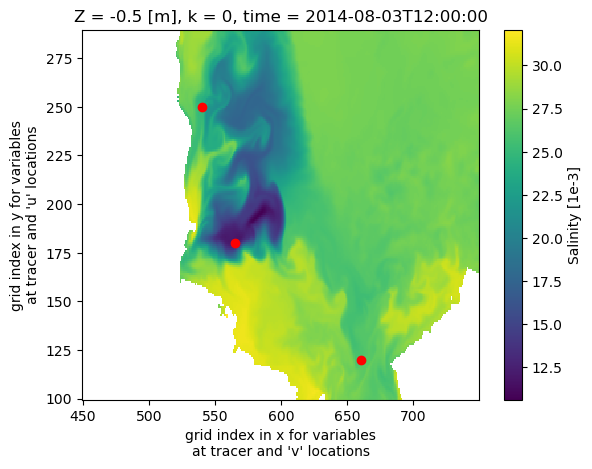

In [9]:
# plot Beaufort Sea area
salt_day.isel(k=0,i=slice(450,750),j=slice(100,290),time=200).plot();
plt.scatter(565,180,c='r');
plt.scatter(540,250,c='r');
plt.scatter(660,120,c='r');